In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def convert_color(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [18]:
capture = cv2.VideoCapture(r"vtest.avi")

In [19]:
capture.get(cv2.CAP_PROP_FRAME_COUNT)

795.0

In [20]:
random_frames = capture.get(cv2.CAP_PROP_FRAME_COUNT)*np.random.uniform(size =30) # get 30 random frames

In [21]:
random_frames[0]

np.float64(468.8589343355048)

In [22]:
frames = []
for frame_id in random_frames:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = capture.read()
    frames.append(frame)
capture.release()

In [26]:
len(frames)

30

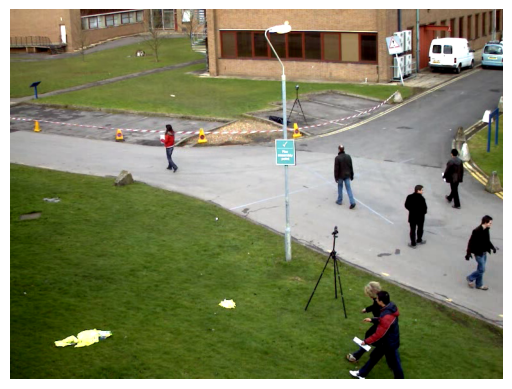

In [33]:
plt.imshow(convert_color(frames[29]))
plt.axis('off')
plt.show()

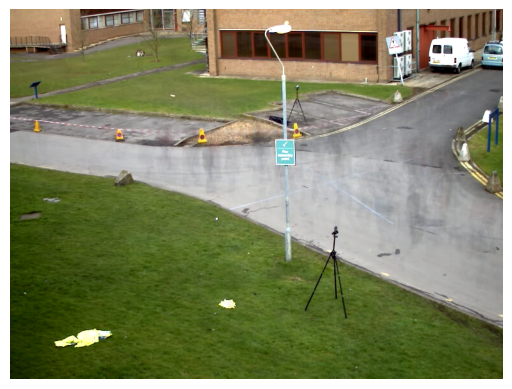

In [34]:
fram_avg = np.average(frames, axis=0).astype(np.uint8)
plt.imshow(convert_color(fram_avg))
plt.axis('off')
plt.show()

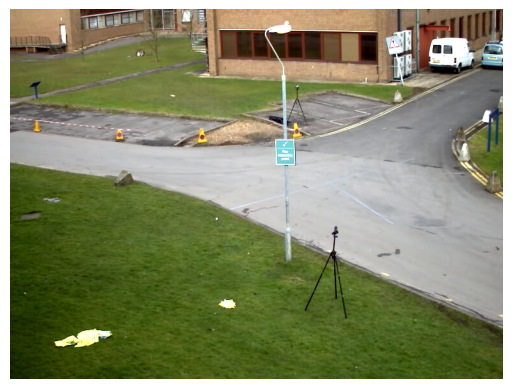

In [35]:
fram_median = np.median(frames, axis=0).astype(np.uint8)
plt.imshow(convert_color(fram_median))
plt.axis('off')
plt.show()

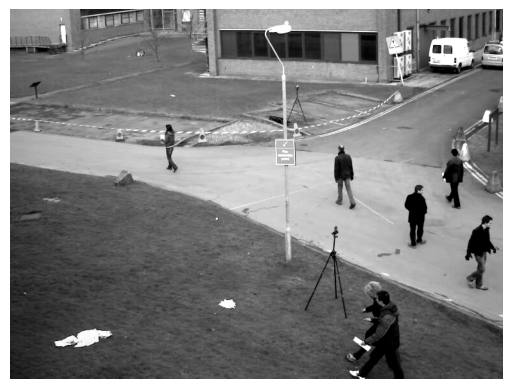

In [37]:
ftame1 = frames[29]
gray_frame = cv2.cvtColor(ftame1, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_frame, cmap='gray')
plt.axis('off')
plt.show()

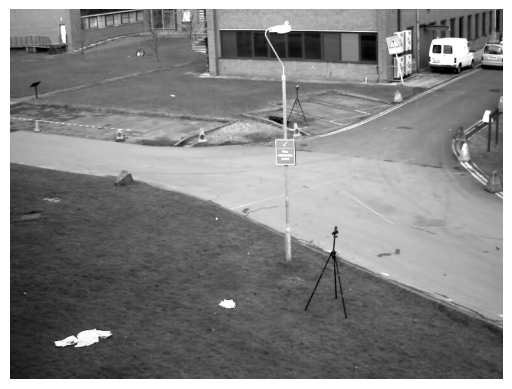

In [38]:
fram_median = np.median(frames, axis=0).astype(np.uint8)
gray_background = cv2.cvtColor(fram_median, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_background, cmap='gray')
plt.axis('off')
plt.show()

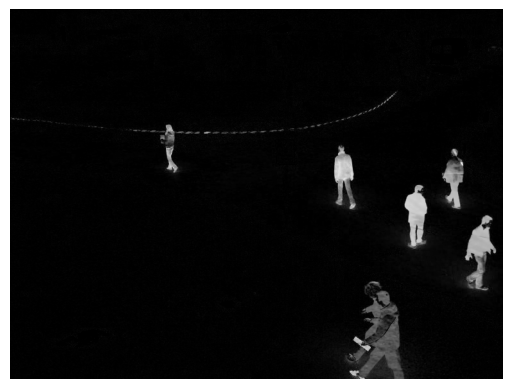

In [40]:
background_remove = cv2.absdiff(gray_frame, gray_background)
plt.imshow(background_remove, cmap='gray')
plt.axis('off')
plt.show()

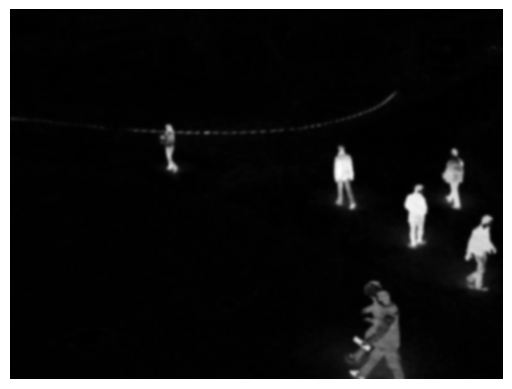

In [41]:
frame_blur = cv2.GaussianBlur(background_remove, (11,11),0)
plt.imshow(frame_blur, cmap='gray')
plt.axis('off')
plt.show()

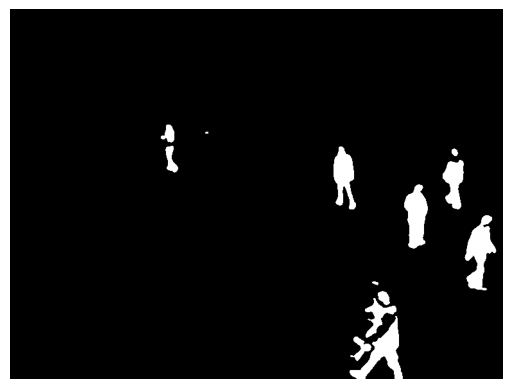

In [45]:
_,frames_trs = cv2.threshold(frame_blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(convert_color(frames_trs), cmap='gray')
plt.axis('off')
plt.show()

In [46]:
(contours, _) = cv2.findContours(frames_trs, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

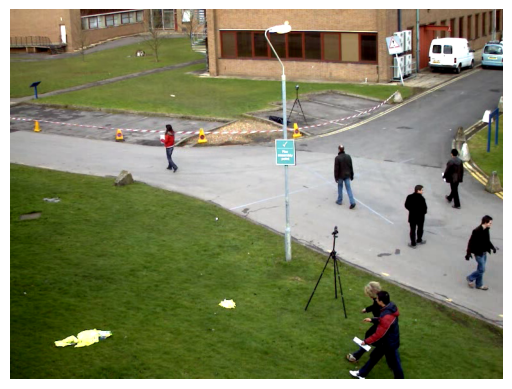

In [50]:
plt.imshow(convert_color(ftame1))
plt.axis('off')
plt.show()

In [51]:
for contour in contours:
    x,y,w,h = cv2.boundingRect(contour)
    cv2.rectangle(ftame1, (x,y), (x+w, y+h), (0,0,255), 2)

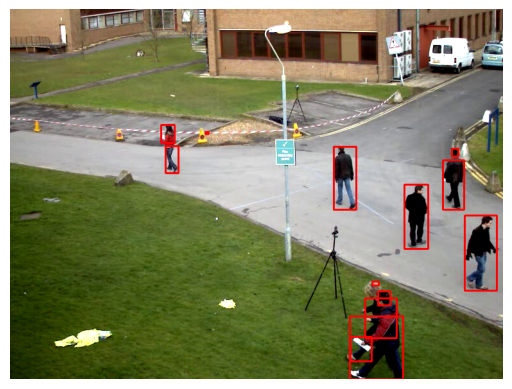

In [52]:
plt.imshow(convert_color(ftame1))
plt.axis('off')
plt.show()

In [60]:
captures = cv2.VideoCapture(r"background video _ people _ walking _.mp4")
background_sub = cv2.createBackgroundSubtractorMOG2()


while captures.isOpened():
    ret, frame = captures.read()
    if not ret:
        break
    
    fg_mask = background_sub.apply(frame)
    (contours, _) = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.contourArea(contour) >500 :
            x,y,w,h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,0,255), 1)
    cv2.imshow("Original Frame", frame)
    cv2.imshow("Foreground Mask", fg_mask)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break
captures.release()
cv2.destroyAllWindows()